# MAPLES-DR Dataset — Exploratory Data Analysis
**Objective:** วิเคราะห์ความครบถ้วน, การกระจายตัว, และคุณภาพข้อมูลของ Dataset  
**Dataset:** MESSIDOR images + MAPLES-DR segmentation masks  
**Target Classes:** OpticDisc, Macula, Exudates, Hemorrhages, Microaneurysms, Drusens

---
## Notebook Structure
| Step | Topic |
|------|-------|
| 1 | Dataset Inventory |
| 2 | True Lesion Presence (Non-Empty Masks) |
| 3 | Pixel-Level Area Statistics |
| 4 | Spatial Heatmaps |
| 5 | Filtered Stats for Target Classes |
| 6 | Visual Audit (Overlay) |
| 7 | Image Resolution & Aspect Ratio |
| 8 | Lesion Area Percentage (Log Scale) |
| 9 | Multi-label Co-occurrence Matrix |
| 10 | Color Intensity Distribution |

## 0. Configuration & Imports

In [1]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from matplotlib.lines import Line2D

# ── Plot Style ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

# ── Dataset Paths ────────────────────────────────────────────────────────────
COLLECTION_DIR    = r"D:\MesidorDataset\MAPLES_Matched"
COLLECTION_IMAGES = os.path.join(COLLECTION_DIR, "images")
COLLECTION_MASKS  = os.path.join(COLLECTION_DIR, "masks")

# ── Target Classes for Analysis ──────────────────────────────────────────────
TARGET_CLASSES = ["OpticDisc", "Macula", "Exudates", "Hemorrhages", "Microaneurysms", "Drusens"]

# ── Palette (per class, RGB) ──────────────────────────────────────────────────
CLASS_COLORS = {
    "OpticDisc":     (255,   0,   0),   # Red
    "Macula":        (  0, 255,   0),   # Green
    "Exudates":      (255, 255,   0),   # Yellow
    "Hemorrhages":   (255,   0, 255),   # Magenta
    "Microaneurysms":(  0, 255, 255),   # Cyan
    "Drusens":       (255, 165,   0),   # Orange
}

---
## Step 1 — Dataset Inventory
ตรวจสอบว่าหลังจากรวมไฟล์ใน `MAPLES_Matched` แล้ว ทุกคลาสมีไฟล์ครบตามที่ควรจะเป็นหรือไม่

Total Unique Images : 198
Total Classes Found : 12



,Class,File_Count
0,BrightUncertains,198
1,CottonWoolSpots,198
2,Drusens,198
3,Exudates,198
4,Hemorrhages,198
5,Macula,197
6,Microaneurysms,198
7,Neovascularization,198
8,OpticCup,192
9,OpticDisc,198


C:\Users\natth\AppData\Local\Temp\ipykernel_19124\1672733880.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_inventory, x="Class", y="File_Count", ax=ax, palette="Set2")


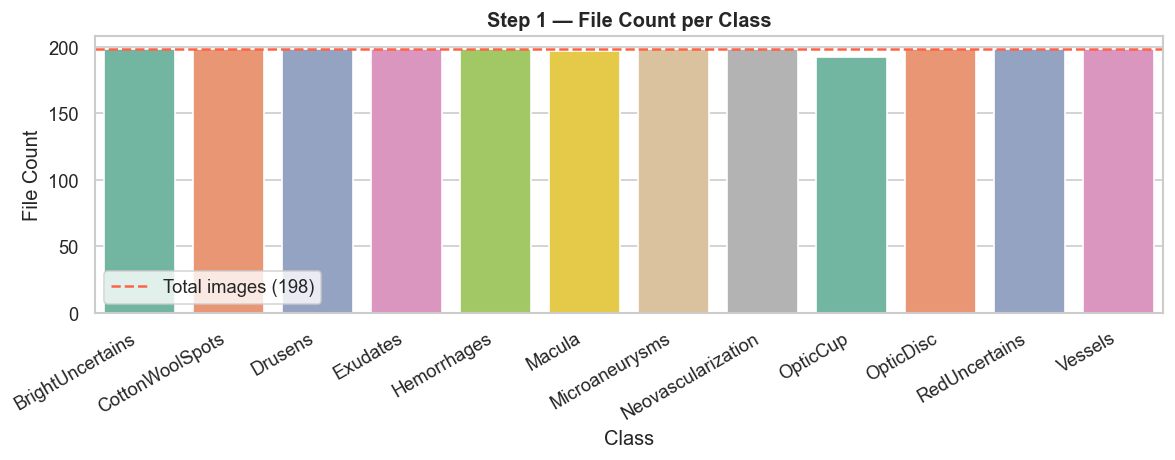

In [2]:
# ── Inventory scan ────────────────────────────────────────────────────────────
total_images     = len([f for f in os.listdir(COLLECTION_IMAGES)
                        if f.lower().endswith((".png", ".tif", ".jpg"))])
available_classes = sorted([d for d in os.listdir(COLLECTION_MASKS)
                             if os.path.isdir(os.path.join(COLLECTION_MASKS, d))])

inventory = [
    {"Class": cls, "File_Count": len(os.listdir(os.path.join(COLLECTION_MASKS, cls)))}
    for cls in available_classes
]
df_inventory = pd.DataFrame(inventory)

print(f"Total Unique Images : {total_images}")
print(f"Total Classes Found : {len(available_classes)}\n")
display(df_inventory)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=df_inventory, x="Class", y="File_Count", ax=ax, palette="Set2")
ax.axhline(total_images, ls="--", color="tomato", label=f"Total images ({total_images})")
ax.set_title("Step 1 — File Count per Class", fontweight="bold")
ax.set_xlabel("Class"); ax.set_ylabel("File Count")
ax.legend(); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

---
## Step 2 — True Lesion Presence (Non-Empty Masks)
ทุกโฟลเดอร์มี 198 ไฟล์เท่ากัน แต่ส่วนใหญ่เป็น Mask ว่างเปล่า (สีดำ)  
→ นับเฉพาะ Mask ที่มีพิกเซลรอยโรคจริงๆ (`pixel > 0`)

Scanning Masks: 100%|██████████| 12/12 [00:22<00:00,  1.84s/it]


,Class,Total_Files,Actual_Present,Presence_Rate_%
9,OpticDisc,198,198,100.0
11,Vessels,198,198,100.0
5,Macula,197,197,100.0
8,OpticCup,192,192,100.0
6,Microaneurysms,198,191,96.5
4,Hemorrhages,198,122,61.6
3,Exudates,198,104,52.5
2,Drusens,198,90,45.5
0,BrightUncertains,198,68,34.3
1,CottonWoolSpots,198,61,30.8


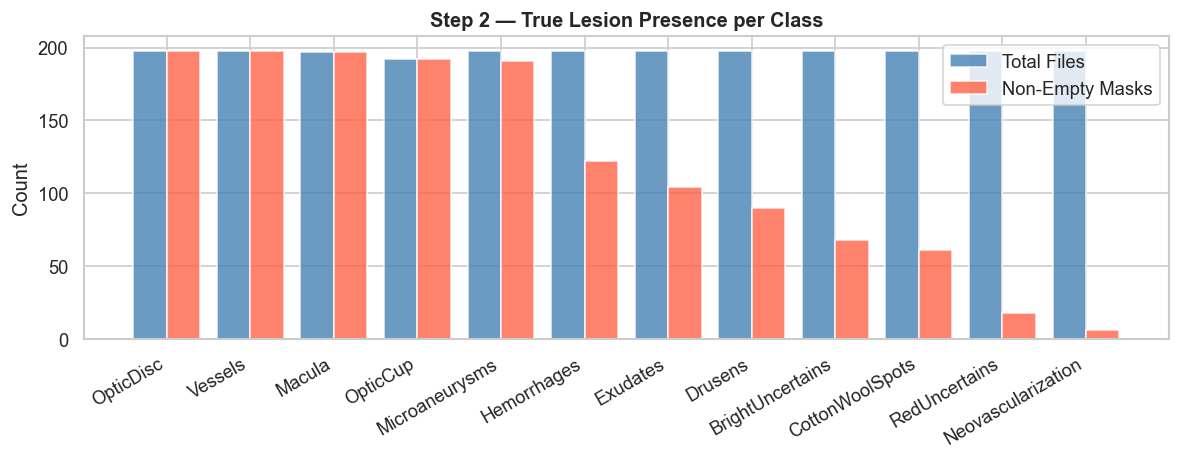

In [3]:
presence_stats = []

for cls in tqdm(available_classes, desc="Scanning Masks"):
    cls_path   = os.path.join(COLLECTION_MASKS, cls)
    mask_files = os.listdir(cls_path)
    n_present  = sum(
        np.any(np.array(Image.open(os.path.join(cls_path, f)).convert("L")) > 0)
        for f in mask_files
    )
    presence_stats.append({
        "Class":           cls,
        "Total_Files":     len(mask_files),
        "Actual_Present":  n_present,
        "Presence_Rate_%": round(n_present / len(mask_files) * 100, 1),
    })

df_presence = pd.DataFrame(presence_stats).sort_values("Actual_Present", ascending=False)
display(df_presence)

# ── Grouped bar: Total vs Present ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(df_presence))
ax.bar(x - 0.2, df_presence["Total_Files"],    0.4, label="Total Files",     color="steelblue", alpha=0.8)
ax.bar(x + 0.2, df_presence["Actual_Present"], 0.4, label="Non-Empty Masks", color="tomato",    alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(df_presence["Class"], rotation=30, ha="right")
ax.set_title("Step 2 — True Lesion Presence per Class", fontweight="bold")
ax.set_ylabel("Count"); ax.legend(); plt.tight_layout(); plt.show()

---
## Step 3 — Pixel-Level Area Statistics
"มีกี่รูป" ≠ "รอยโรคใหญ่แค่ไหน"  
→ คำนวณ avg / max / min pixel area **เฉพาะ Mask ที่มีรอยโรคจริงๆ**

Pixel Area: 100%|██████████| 12/12 [00:19<00:00,  1.62s/it]


,Class,N_Positive,Avg_Pixel_Area,Median_Pixel_Area,Max_Pixel_Area,Min_Pixel_Area
11,Vessels,198,167839.4,126427,352885,40934
7,Neovascularization,6,40782.2,14423,116544,90
9,OpticDisc,198,22994.3,18592,52214,6447
3,Exudates,104,8633.9,1964,88457,38
4,Hemorrhages,122,5536.6,1383,111503,55
8,OpticCup,192,4222.2,3624,18107,192
1,CottonWoolSpots,61,3361.2,1335,23988,151
6,Microaneurysms,191,3275.7,1555,28386,33
0,BrightUncertains,68,2156.9,402,67228,35
2,Drusens,90,1941.7,502,23307,33


C:\Users\natth\AppData\Local\Temp\ipykernel_19124\2400882988.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pixel, x="Class", y="Avg_Pixel_Area", ax=ax, palette="coolwarm")


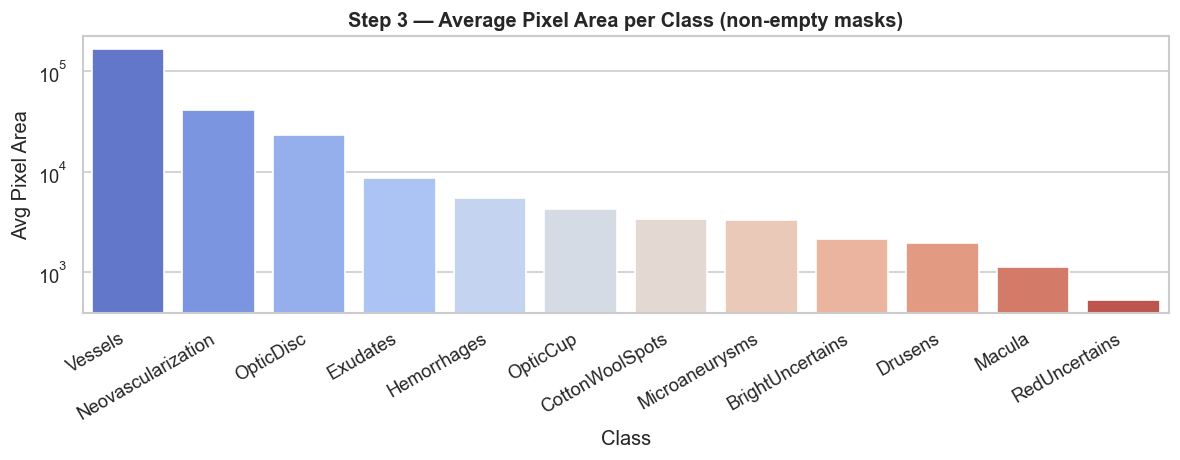

In [4]:
pixel_stats = []

for cls in tqdm(available_classes, desc="Pixel Area"):
    cls_path = os.path.join(COLLECTION_MASKS, cls)
    areas    = [
        int(np.sum(np.array(Image.open(os.path.join(cls_path, f)).convert("L")) > 0))
        for f in os.listdir(cls_path) if f.endswith(".png")
    ]
    areas = [a for a in areas if a > 0]   # keep non-empty only
    if areas:
        pixel_stats.append({
            "Class":            cls,
            "N_Positive":       len(areas),
            "Avg_Pixel_Area":   round(float(np.mean(areas)), 1),
            "Median_Pixel_Area":int(np.median(areas)),
            "Max_Pixel_Area":   int(np.max(areas)),
            "Min_Pixel_Area":   int(np.min(areas)),
        })

df_pixel = pd.DataFrame(pixel_stats).sort_values("Avg_Pixel_Area", ascending=False)
display(df_pixel)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=df_pixel, x="Class", y="Avg_Pixel_Area", ax=ax, palette="coolwarm")
ax.set_title("Step 3 — Average Pixel Area per Class (non-empty masks)", fontweight="bold")
ax.set_xlabel("Class"); ax.set_ylabel("Avg Pixel Area")
ax.set_yscale("log")   # log scale — areas differ by orders of magnitude
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

---
## Step 4 — Spatial Heatmaps
แผนที่ความร้อน: แต่ละคลาสมักโผล่ตรงไหนของภาพ?  
ใช้เพื่อตรวจสอบว่า Preprocessing (Center Crop / Alignment) ได้ผลดีหรือยัง

Spatial Heatmaps: 100%|██████████| 12/12 [00:10<00:00,  1.13it/s]


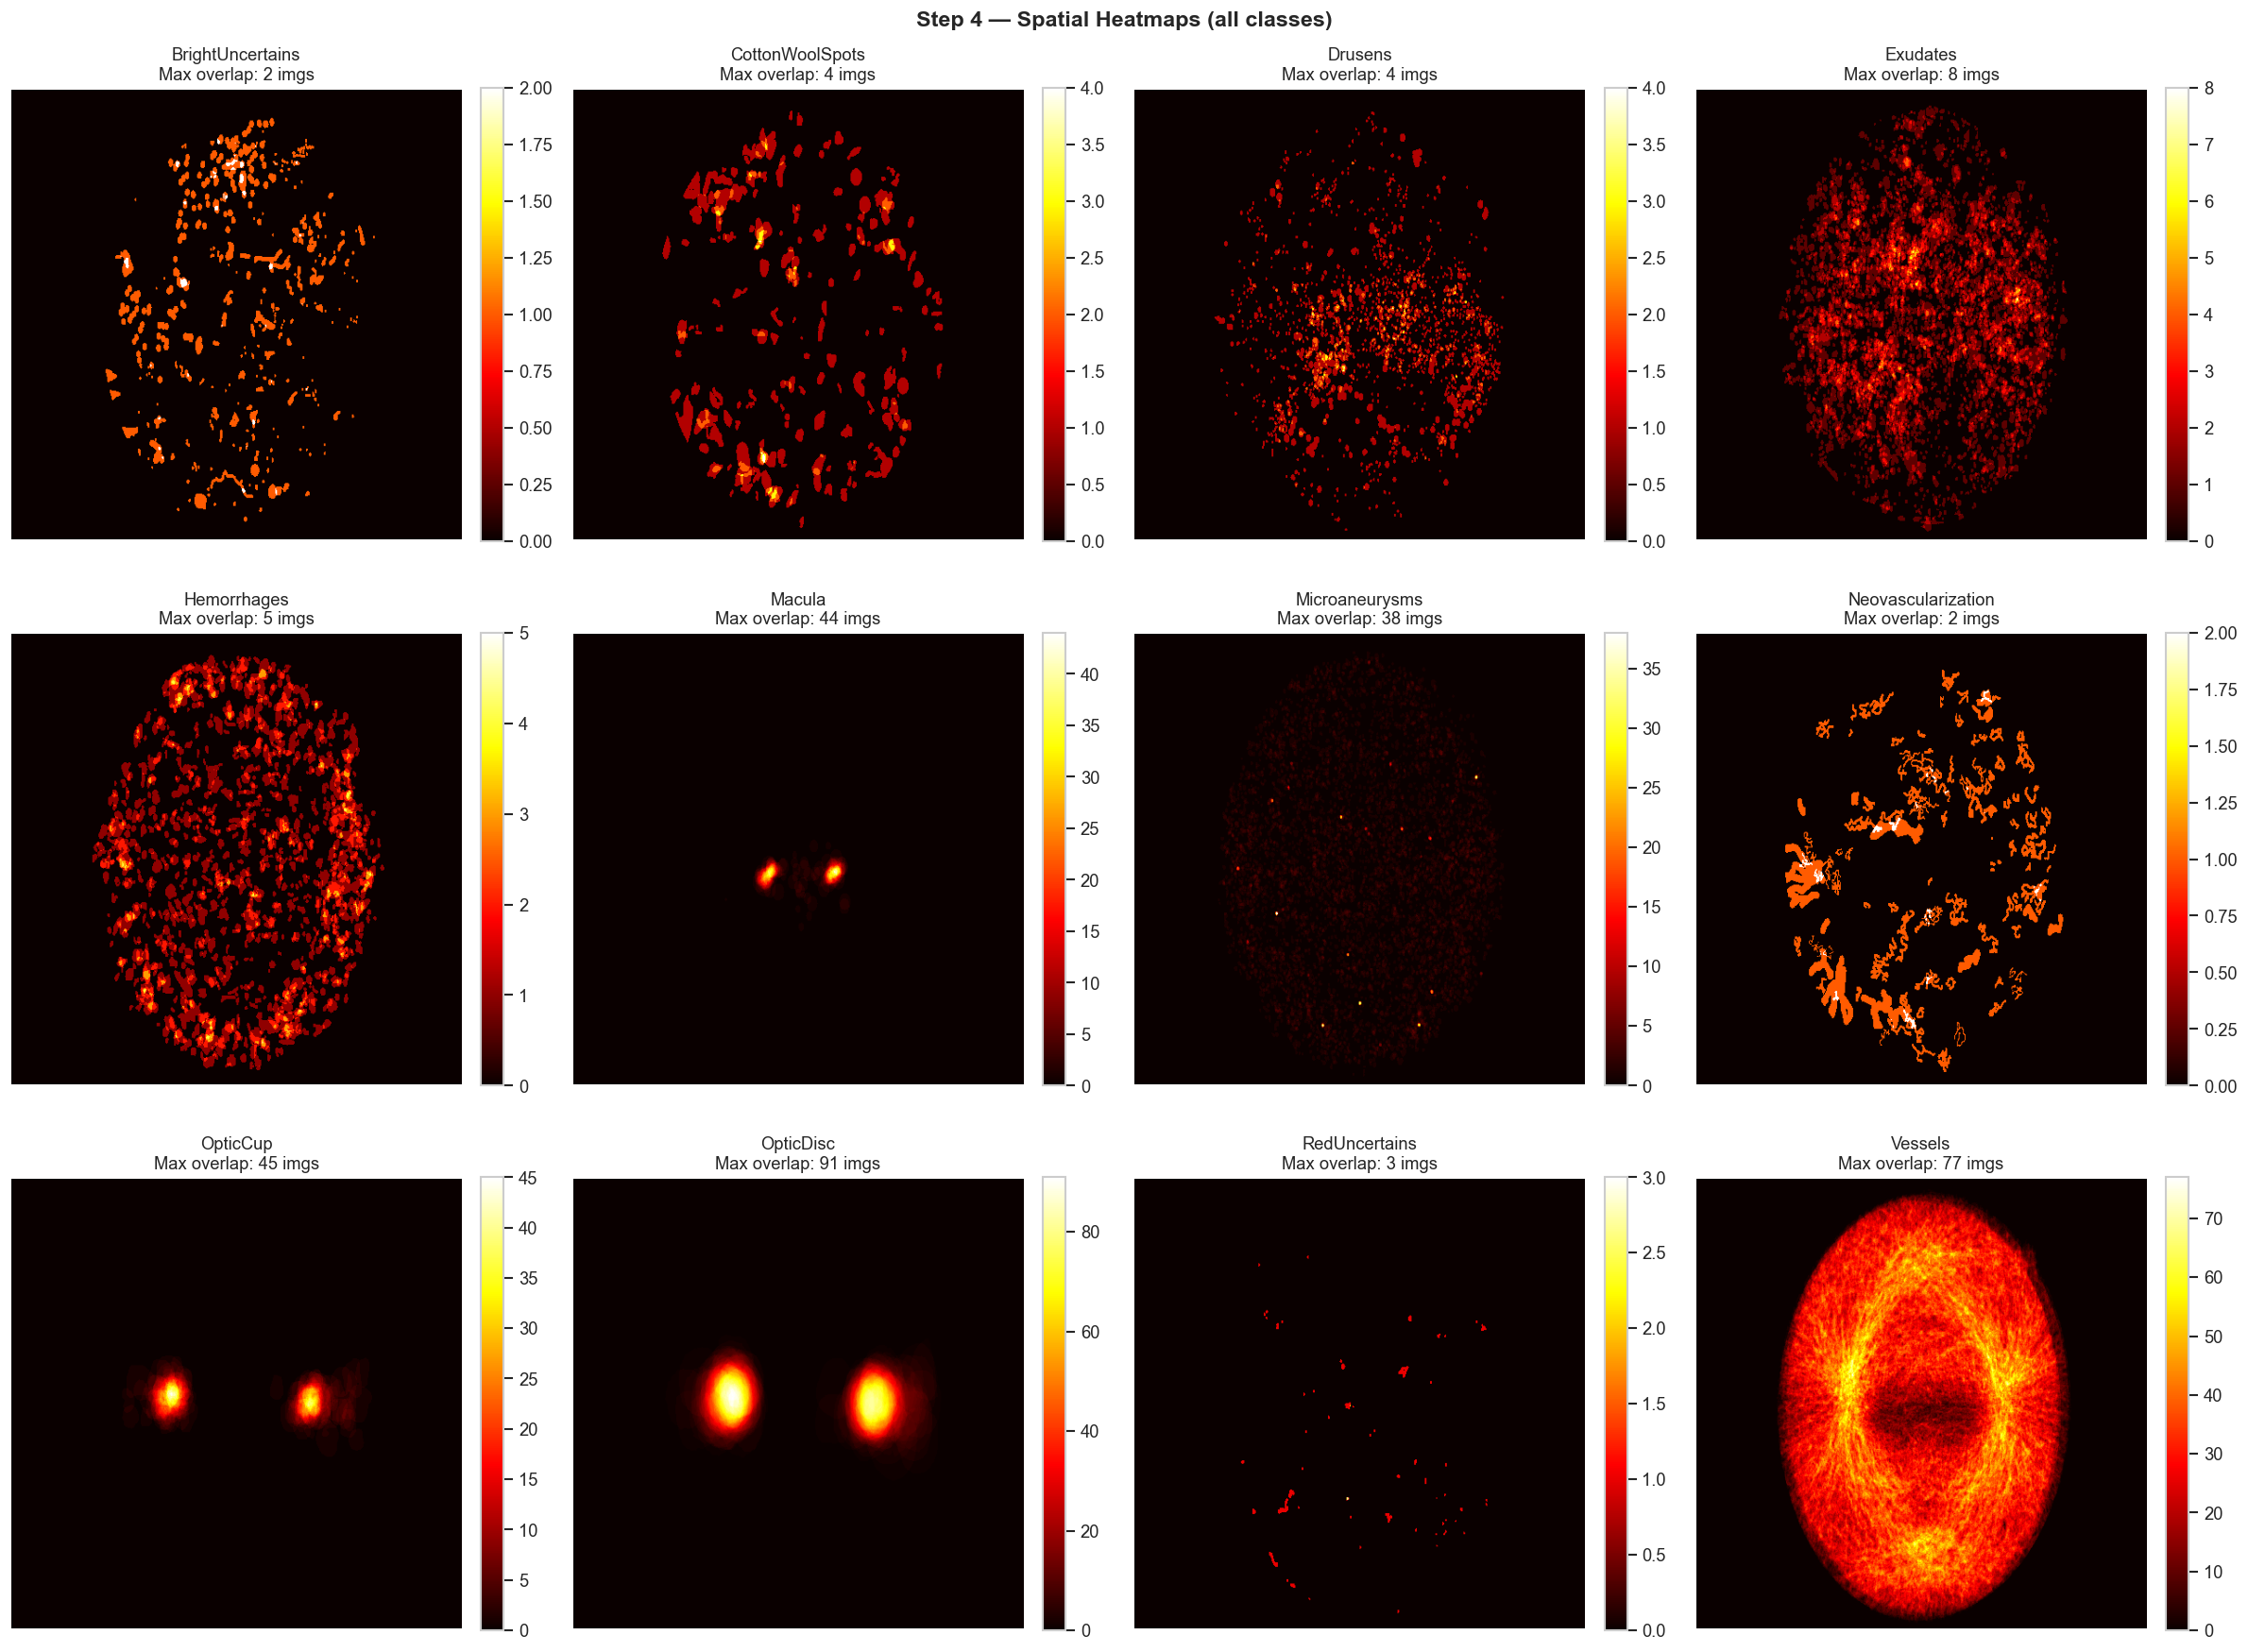

In [5]:
HEATMAP_SIZE = (512, 512)
heatmaps     = {cls: np.zeros(HEATMAP_SIZE, dtype=np.float32) for cls in available_classes}

for cls in tqdm(available_classes, desc="Spatial Heatmaps"):
    cls_path = os.path.join(COLLECTION_MASKS, cls)
    for fname in os.listdir(cls_path):
        mask = Image.open(os.path.join(cls_path, fname)).convert("L").resize(HEATMAP_SIZE, Image.NEAREST)
        heatmaps[cls] += np.array(mask) > 0

# ── Subplot grid ──────────────────────────────────────────────────────────────
COLS = 4
ROWS = -(-len(available_classes) // COLS)   # ceiling division
fig, axes = plt.subplots(ROWS, COLS, figsize=(20, 5 * ROWS))
axes = axes.flatten()

for i, cls in enumerate(available_classes):
    ax  = axes[i]
    im  = ax.imshow(heatmaps[cls], cmap="hot")
    ax.set_title(f"{cls}\nMax overlap: {int(heatmaps[cls].max())} imgs", fontsize=11)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Step 4 — Spatial Heatmaps (all classes)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

---
## Step 5 — Filtered Stats for Target Classes
กรองสถิติเฉพาะ 6 คลาสที่ใช้ในโปรเจกต์จริง

In [6]:
df_presence_focus = (
    df_presence[df_presence["Class"].isin(TARGET_CLASSES)]
    .sort_values("Presence_Rate_%", ascending=False)
    .reset_index(drop=True)
)
df_pixel_focus = (
    df_pixel[df_pixel["Class"].isin(TARGET_CLASSES)]
    .sort_values("Avg_Pixel_Area", ascending=False)
    .reset_index(drop=True)
)

print("=== Presence Stats (Target Classes) ===")
display(df_presence_focus)
print("\n=== Pixel Area Stats (Target Classes) ===")
display(df_pixel_focus)

=== Presence Stats (Target Classes) ===


,Class,Total_Files,Actual_Present,Presence_Rate_%
0,OpticDisc,198,198,100.0
1,Macula,197,197,100.0
2,Microaneurysms,198,191,96.5
3,Hemorrhages,198,122,61.6
4,Exudates,198,104,52.5
5,Drusens,198,90,45.5



=== Pixel Area Stats (Target Classes) ===


,Class,N_Positive,Avg_Pixel_Area,Median_Pixel_Area,Max_Pixel_Area,Min_Pixel_Area
0,OpticDisc,198,22994.3,18592,52214,6447
1,Exudates,104,8633.9,1964,88457,38
2,Hemorrhages,122,5536.6,1383,111503,55
3,Microaneurysms,191,3275.7,1555,28386,33
4,Drusens,90,1941.7,502,23307,33
5,Macula,197,1125.7,907,7048,33


---
## Step 6 — Visual Audit (Random Image Overlay)
สุ่มดูภาพ 1 ใบพร้อม Overlay Mask ทั้ง 6 คลาสเพื่อตรวจสอบคุณภาพ Annotation

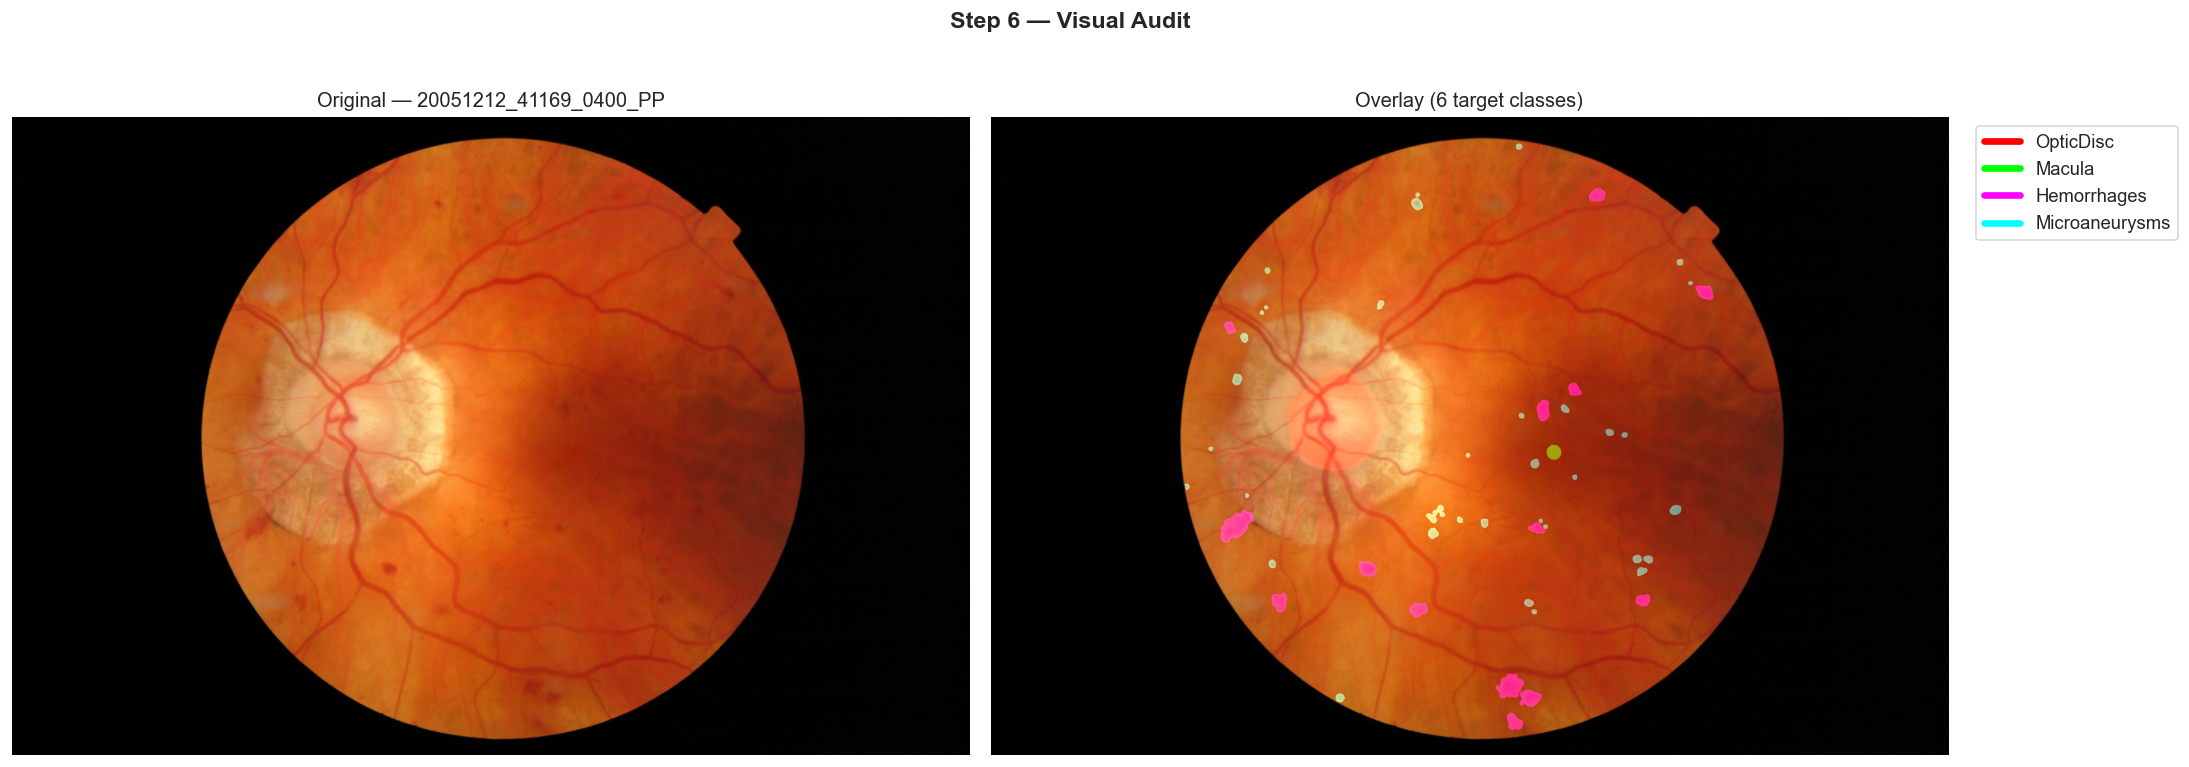

In [7]:
all_image_paths = glob.glob(os.path.join(COLLECTION_IMAGES, "*"))
sample_path     = all_image_paths[np.random.randint(len(all_image_paths))]
img_id          = os.path.splitext(os.path.basename(sample_path))[0]

img_bgr  = cv2.imread(sample_path)
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
overlay  = img_rgb.copy()

legend_handles = []
for cls in TARGET_CLASSES:
    color      = CLASS_COLORS[cls]
    mask_path  = os.path.join(COLLECTION_MASKS, cls, f"{img_id}.png")
    if not os.path.exists(mask_path):
        continue
    mask = np.array(Image.open(mask_path).convert("L"))
    if np.any(mask > 0):
        colored = np.zeros_like(img_rgb)
        colored[mask > 0] = color
        overlay = cv2.addWeighted(overlay, 1.0, colored, 0.5, 0)
        legend_handles.append(Line2D([0], [0], color=np.array(color) / 255, lw=4, label=cls))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].imshow(img_rgb);  axes[0].set_title(f"Original — {img_id}");  axes[0].axis("off")
axes[1].imshow(overlay);  axes[1].set_title("Overlay (6 target classes)"); axes[1].axis("off")
if legend_handles:
    axes[1].legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(1.25, 1))
fig.suptitle("Step 6 — Visual Audit", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

---
## Step 7 — Image Resolution & Aspect Ratio
ภาพจาก MESSIDOR มาจากกล้องหลายยี่ห้อ → ตรวจสอบความสม่ำเสมอของ Resolution

=== Resolution Value Counts ===
Width  Height
1440   960       104
2240   1488       53
2304   1536       41


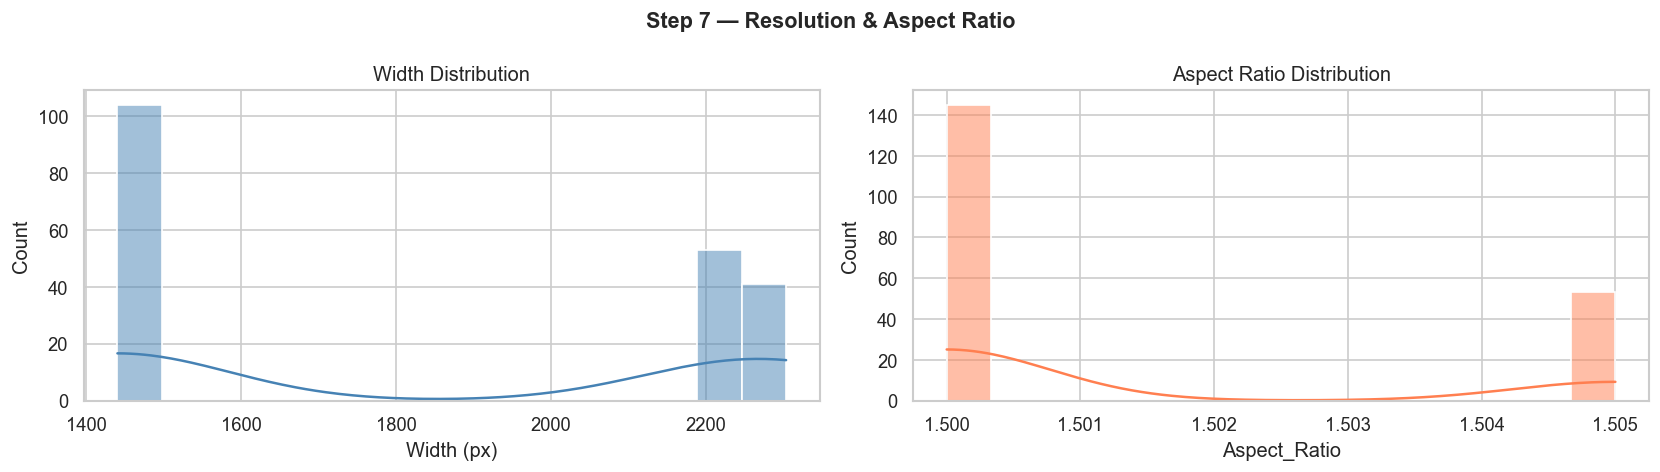

In [8]:
res_data = []
for img_path in glob.glob(os.path.join(COLLECTION_IMAGES, "*")):
    with Image.open(img_path) as im:
        w, h = im.size
        res_data.append({"Width": w, "Height": h, "Aspect_Ratio": round(w / h, 3)})

df_res = pd.DataFrame(res_data)
print("=== Resolution Value Counts ===")
print(df_res[["Width", "Height"]].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_res["Width"],        bins=15, ax=axes[0], color="steelblue", kde=True)
axes[0].set_title("Width Distribution"); axes[0].set_xlabel("Width (px)")
sns.histplot(df_res["Aspect_Ratio"], bins=15, ax=axes[1], color="coral",     kde=True)
axes[1].set_title("Aspect Ratio Distribution")
fig.suptitle("Step 7 — Resolution & Aspect Ratio", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

---
## Step 8 — Lesion Area Percentage (Log Scale)
รอยโรคแต่ละคลาสคิดเป็น % ของพื้นที่ภาพเท่าไร? → ช่วยวางแผน Loss Function

C:\Users\natth\AppData\Local\Temp\ipykernel_19124\1152539478.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_area, x="Area_%", y="Class",


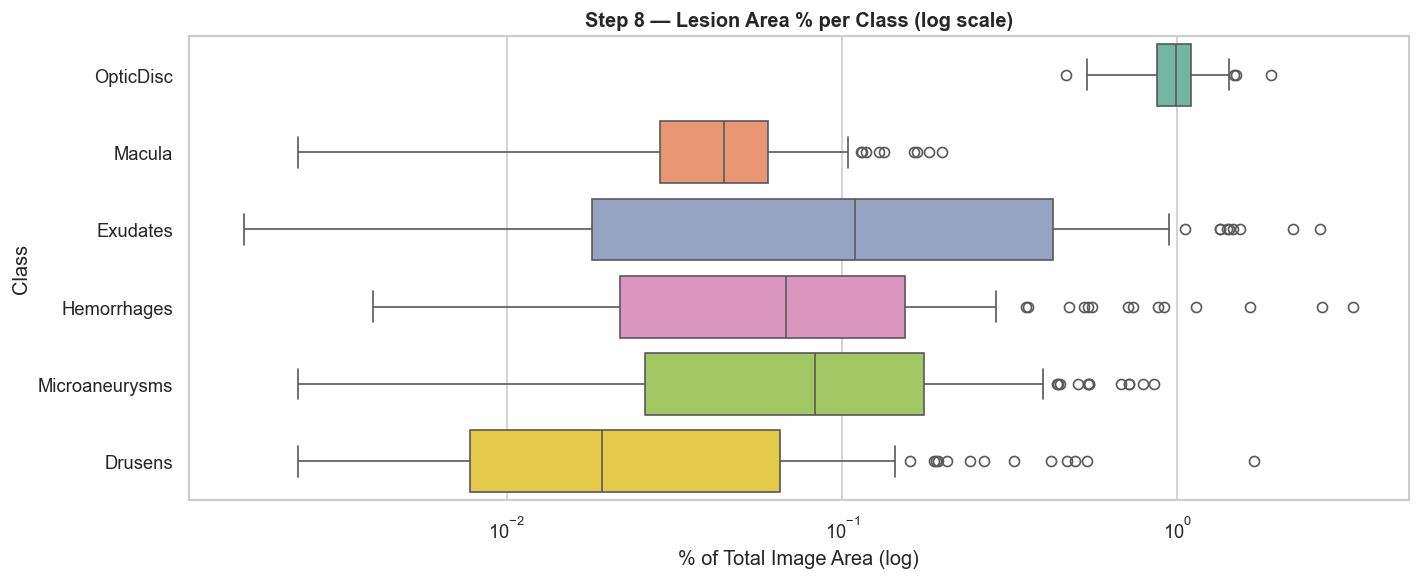

In [9]:
area_pct = []
for cls in TARGET_CLASSES:
    cls_path = os.path.join(COLLECTION_MASKS, cls)
    for fname in os.listdir(cls_path):
        mask          = np.array(Image.open(os.path.join(cls_path, fname)).convert("L"))
        lesion_pixels = int(np.sum(mask > 0))
        if lesion_pixels > 0:
            area_pct.append({"Class": cls, "Area_%": lesion_pixels / mask.size * 100})

df_area = pd.DataFrame(area_pct)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_area, x="Area_%", y="Class",
            order=TARGET_CLASSES, palette="Set2", ax=ax)
ax.set_xscale("log")
ax.set_title("Step 8 — Lesion Area % per Class (log scale)", fontweight="bold")
ax.set_xlabel("% of Total Image Area (log)")
plt.tight_layout(); plt.show()

---
## Step 9 — Multi-label Co-occurrence Matrix
### 9a. Number of Classes per Image
### 9b. Class Correlation Heatmap (รอยโรคไหนชอบมาคู่กัน?)

In [10]:
# ── Build binary presence matrix ──────────────────────────────────────────────
all_img_ids  = [os.path.splitext(f)[0] for f in os.listdir(COLLECTION_IMAGES)
                if f.lower().endswith((".png", ".tif", ".jpg"))]
occurrence   = []

for img_id in tqdm(all_img_ids, desc="Building presence matrix"):
    row = {"Image_ID": img_id}
    for cls in TARGET_CLASSES:
        mask_path = os.path.join(COLLECTION_MASKS, cls, f"{img_id}.png")
        if os.path.exists(mask_path):
            mask    = np.array(Image.open(mask_path).convert("L"))
            row[cls] = 1 if np.any(mask > 0) else 0
        else:
            row[cls] = 0
    occurrence.append(row)

df_occ = pd.DataFrame(occurrence)
df_occ["N_Classes"] = df_occ[TARGET_CLASSES].sum(axis=1)

Building presence matrix: 100%|██████████| 198/198 [00:06<00:00, 28.31it/s]


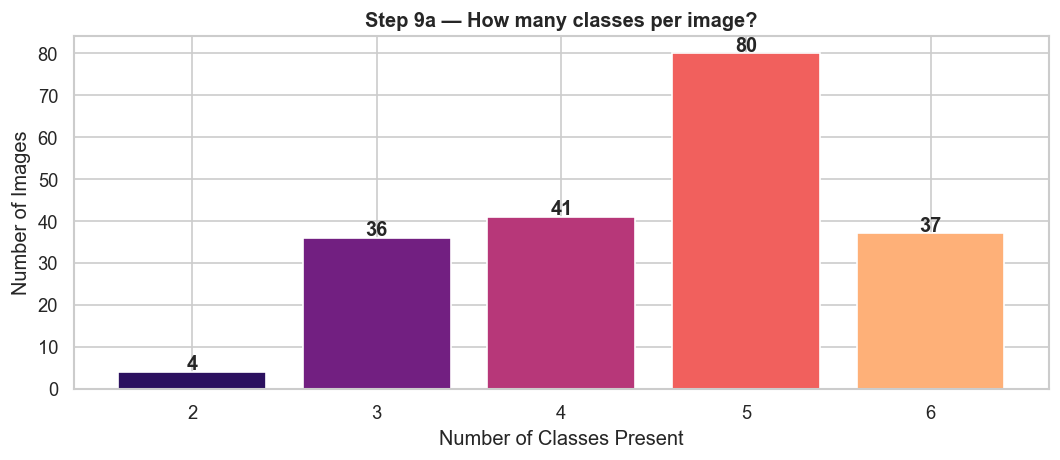

N_Classes
2     4
3    36
4    41
5    80
6    37


In [11]:
# ── 9a: Label count distribution ──────────────────────────────────────────────
class_counts = df_occ["N_Classes"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(class_counts.index, class_counts.values,
              color=sns.color_palette("magma", len(class_counts)))
for bar, v in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5,
            str(v), ha="center", fontweight="bold")
ax.set_title("Step 9a — How many classes per image?", fontweight="bold")
ax.set_xlabel("Number of Classes Present"); ax.set_ylabel("Number of Images")
plt.tight_layout(); plt.show()

print(class_counts.to_string())

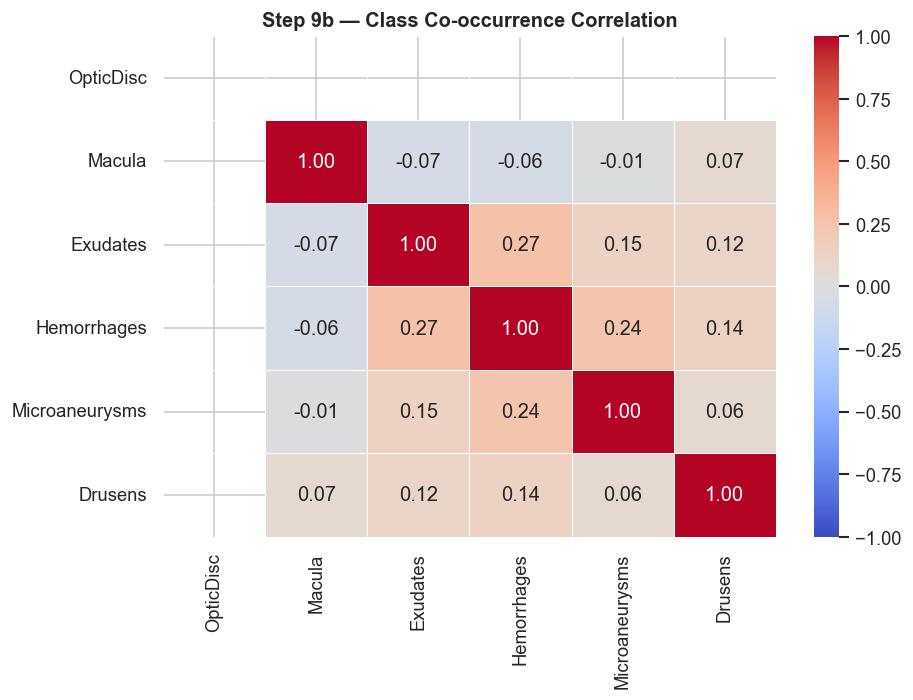

In [12]:
# ── 9b: Correlation heatmap ────────────────────────────────────────────────────
corr = df_occ[TARGET_CLASSES].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, vmin=-1, vmax=1, ax=ax)
ax.set_title("Step 9b — Class Co-occurrence Correlation", fontweight="bold")
plt.tight_layout(); plt.show()

---
## Step 10 — Color Intensity Distribution
ภาพจากกล้องต่างยี่ห้อกัน → ตรวจสอบความแปรปรวนของ RGB เพื่อวางแผน Color Normalization

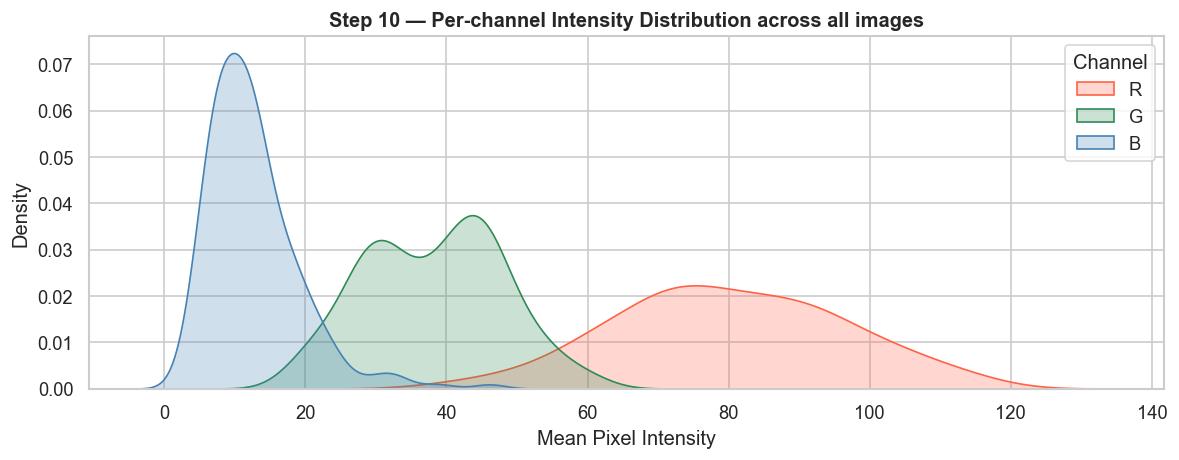

=== Per-channel Statistics ===


,B,G,R
count,198.00,198.00,198.00
mean,12.62,38.15,80.07
std,6.50,9.68,16.16
min,3.04,18.04,38.38
25%,8.06,30.58,69.02
50%,11.42,39.15,79.65
75%,15.35,45.45,91.99
max,46.11,61.35,117.94


In [13]:
mean_colors = []
for img_path in glob.glob(os.path.join(COLLECTION_IMAGES, "*")):
    img = cv2.imread(img_path)                # BGR
    if img is None:
        continue
    mean_colors.append(img.reshape(-1, 3).mean(axis=0))   # [B, G, R]

df_color = pd.DataFrame(mean_colors, columns=["B", "G", "R"])

fig, ax = plt.subplots(figsize=(10, 4))
for ch, color in zip(["R", "G", "B"], ["tomato", "seagreen", "steelblue"]):
    sns.kdeplot(df_color[ch], ax=ax, color=color, label=ch, fill=True, alpha=0.25)
ax.set_title("Step 10 — Per-channel Intensity Distribution across all images", fontweight="bold")
ax.set_xlabel("Mean Pixel Intensity"); ax.set_ylabel("Density")
ax.legend(title="Channel")
plt.tight_layout(); plt.show()

print("=== Per-channel Statistics ===")
display(df_color.describe().round(2))